# A music visualizer: the trig-rose driven by sound instead of an abstract clock

Old Windows Media Player visualizers turned an audio stream's energy and frequency content into geometry in real time -- bars jumping with the bass, ripples reacting to a kick drum. Every rose and quasicrystal field in this `drawing/` folder so far has been driven by an abstract clock (an irrational number, a phase parameter). This notebook drives the exact same rose formula from the first notebook -- `r(theta) = R0 + amplitude * cos(n*theta + phase)` -- with something that actually has dynamics: a synthesized audio signal shaped like the classic "long quiet passage, then the whole band slams in with a fast riff" structure (the thing that makes the *Master of Puppets* intro so effective).

**Important:** this notebook does not sample, transcribe, or reproduce that song. It **synthesizes an original texture from scratch** -- pure trig-function harmonic synthesis plus a rhythmic gate and a soft-clip distortion -- shaped to have the same *silence-then-explosion* dynamic structure, using a generic palm-muted "gallop" rhythm (a standard metal technique, not a specific riff) rather than anyone's actual notes. What drives the visualizer is the signal's own energy envelope, exactly like a real visualizer reacts to whatever you feed it.

In [1]:
import os
import tempfile
import subprocess

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, Video

GOLDEN = (1 + 5 ** 0.5) / 2

## Synthesizing the riff

Ingredients, all just trig functions and simple nonlinearities:

- **Tone**: a harmonic (sawtooth-ish) series `sum (1/k) * sin(2*pi*k*f0*t)` on the low-E guitar fundamental (82.41 Hz) -- a Fourier series built entirely out of sines.
- **Gallop gate**: a fast square-wave pulse train (16th notes at 200 bpm) multiplying the tone on and off, the way a palm-muted chug works.
- **Distortion**: `tanh` soft-clipping to round off the square-gated edges into something that sounds like an overdriven amp rather than a plain buzz.
- **Envelope**: a handful of `[start, end]` windows with a short raised-cosine ramp at each edge, `1` inside a "riff" window and `~0` in the quiet stretches between them -- this is the *only* place the "silence punctuated by riffs" shape gets imposed; everything else is just texture.

In [2]:
SR = 22_050
DURATION = 10.0
t = np.arange(0, DURATION, 1 / SR)

def smooth_gate(t, start, end, ramp=0.015):
    """1 inside [start, end], 0 outside, raised-cosine ramp at each edge."""
    g = np.zeros_like(t)
    rise = (t >= start - ramp) & (t < start)
    g[rise] = 0.5 * (1 - np.cos(np.pi * (t[rise] - (start - ramp)) / ramp))
    hold = (t >= start) & (t <= end)
    g[hold] = 1.0
    fall = (t > end) & (t <= end + ramp)
    g[fall] = 0.5 * (1 + np.cos(np.pi * (t[fall] - end) / ramp))
    return g

RIFF_BURSTS = [(2.0, 2.6), (4.0, 4.5), (6.0, 8.0)]  # quiet ... burst ... quiet ... burst ... longer burst
envelope = np.zeros_like(t)
for start, end in RIFF_BURSTS:
    envelope = np.maximum(envelope, smooth_gate(t, start, end))

F0 = 82.41  # low E
tone = sum((1.0 / k) * np.sin(2 * np.pi * k * F0 * t) for k in range(1, 7))

BPM = 200
note_rate = BPM / 60 * 4  # 16th-note gallop rate
gate_wave = 0.5 * (1 + np.sign(np.sin(2 * np.pi * note_rate * t)))

riff = np.tanh(4 * tone * gate_wave) * envelope
quiet_hum = 0.03 * np.sin(2 * np.pi * F0 * t)  # faint tone under the silence, not true dead air
signal = np.clip(riff + quiet_hum * (1 - envelope) * 0.6, -1, 1)

wav_path = "riff_synth.wav"
wavfile.write(wav_path, SR, (signal * 32767).astype(np.int16))
Audio(wav_path)

Sanity check: does the energy actually look like silence punctuated by riffs?

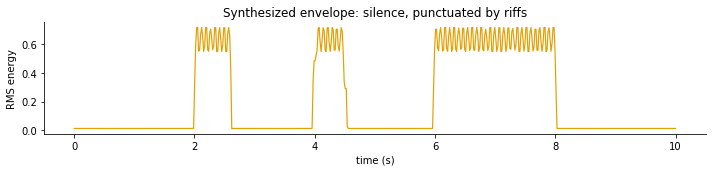

In [3]:
def rms_at(t_center, win=0.06):
    i0 = max(0, int((t_center - win / 2) * SR))
    i1 = min(len(signal), int((t_center + win / 2) * SR))
    seg = signal[i0:i1]
    return np.sqrt(np.mean(seg ** 2)) if len(seg) else 0.0

sample_times = np.linspace(0, DURATION, 600)
rms_curve = [rms_at(tc) for tc in sample_times]

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(sample_times, rms_curve, color="#E69F00", linewidth=1.2)
ax.set_xlabel("time (s)")
ax.set_ylabel("RMS energy")
ax.set_title("Synthesized envelope: silence, punctuated by riffs")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## The visualizer: the same rose, now driven by sound

Same formula as the very first notebook in this folder -- `r(theta) = R0 + amplitude * cos(N*theta + phase)` -- but every quantity that used to come from an irrational number now comes from the audio's own short-time RMS energy at that instant:

- **Amplitude** (how spiky the rose gets) scales directly with the energy -- silence collapses it to a near-perfect circle, a riff blows it out into a sharp 7-petal star.
- **Rotation speed** (`phase`) also speeds up with energy, so the rose spins lazily in the quiet and whips around during a riff.
- **Color** comes from `inferno` keyed to the same energy value, so the shape visually goes from cold and dark to hot and bright exactly when the sound does.

A small oscilloscope-style trace of the raw waveform rides along underneath, the classic second half of an old WMP skin.

In [4]:
FPS = 30
N_PETALS = 7  # same wave count as the quasicrystal field a few notebooks back
theta = np.linspace(0, 2 * np.pi, 720)
cmap = plt.get_cmap("inferno")

frame_dir = tempfile.mkdtemp(prefix="riff_frames_")
n_frames = int(DURATION * FPS)

for i in range(n_frames):
    tc = i / FPS
    env = np.clip(rms_at(tc) / 0.6, 0, 1)
    phase = tc * (1.2 + env * 5)
    r = 1.0 + (0.04 + 0.9 * env) * np.cos(N_PETALS * theta + phase)
    color = cmap(0.12 + 0.75 * env)

    fig = plt.figure(figsize=(5, 5), dpi=90)
    fig.patch.set_facecolor("black")
    ax = fig.add_axes([0, 0, 1, 1], projection="polar")
    ax.set_facecolor("black")
    ax.plot(theta, r, color=color, linewidth=2)
    ax.fill(theta, r, color=color, alpha=0.3)
    ax.set_ylim(0, 2.1)
    ax.axis("off")

    wax = fig.add_axes([0.3, 0.42, 0.4, 0.16])
    i0 = max(0, int((tc - 0.05) * SR))
    i1 = min(len(signal), int((tc + 0.05) * SR))
    wax.plot(signal[i0:i1], color="white", linewidth=0.7)
    wax.set_ylim(-1.1, 1.1)
    wax.axis("off")
    wax.set_facecolor("none")

    fig.savefig(os.path.join(frame_dir, f"f_{i:04d}.png"), facecolor="black")
    plt.close(fig)

print(f"rendered {n_frames} frames to {frame_dir}")

rendered 300 frames to /tmp/riff_frames_r_374v31


In [5]:
video_path = "riff_visualizer.mp4"
result = subprocess.run(
    [
        "ffmpeg", "-y",
        "-framerate", str(FPS),
        "-i", os.path.join(frame_dir, "f_%04d.png"),
        "-i", wav_path,
        "-c:v", "libx264", "-profile:v", "baseline", "-level", "3.0", "-pix_fmt", "yuv420p",
        "-c:a", "aac", "-ar", "44100", "-ac", "1",
        "-shortest", "-movflags", "+faststart",
        video_path,
    ],
    capture_output=True, text=True,
)
assert result.returncode == 0, result.stderr

# frames are just intermediate scratch now that they're muxed into the video
for fname in os.listdir(frame_dir):
    os.remove(os.path.join(frame_dir, fname))
os.rmdir(frame_dir)

Video(video_path, embed=True)

## Takeaways

- The rose formula hasn't changed since the first notebook -- `R0 + amplitude*cos(N*theta + phase)` -- only what's *feeding* it has: an irrational-number clock before, a real (synthesized) signal's own energy now.
- "Silence punctuated by riffs" turned out to live entirely in one array: the envelope. Strip that away and the tone/gate/distortion machinery underneath is just a static texture generator -- the dynamic structure people actually respond to is a single slowly-varying curve.
- Getting the gallop rhythm's timing right mattered more than any of the prettier bits (color, petal count): a plain arithmetic slip (`bpm/60/4*4` silently reducing to `bpm/60`) turned "fast 16th-note chugging" into quarter notes, which was subtle enough to not look obviously wrong until the RMS windows started landing in gaps between notes.
- No copyrighted audio was sampled, transcribed, or reproduced anywhere in this notebook -- the riff is original synthesis shaped only to match a *dynamic contour* (quiet, then loud), using a generic technique (palm-muted gallop), not any specific melody.